# 07 - Player Defensive Archetypes

This notebook creates **individual player defensive archetypes** from event-level defensive actions.

## Questions answered
1. Which players have similar defensive action profiles?
2. Which archetypes are pressers, box defenders, wide protectors, ball winners, or support defenders?
3. Which players are the clearest examples of each archetype?
4. How do archetypes differ by position group and downstream risk?

**Unit of analysis:** one row per player, filtered to players with enough defensive actions for a stable profile.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 8)
RANDOM_STATE = 42

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd()]:
        if (candidate / 'data' / 'features' / 'player_defensive_actions.parquet').exists():
            return candidate
    raise FileNotFoundError('Could not locate data/features/player_defensive_actions.parquet from the current working directory.')

def mode_or_unknown(s: pd.Series) -> str:
    s = s.dropna().astype(str)
    return s.mode().iloc[0] if not s.empty else 'Unknown'

REPO_ROOT = find_repo_root()
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
df = pd.read_parquet(DATA_FEATURES / 'player_defensive_actions.parquet')

print(f'Repository root: {REPO_ROOT}')
print(f'Defensive actions: {len(df):,}')
print(f'Players: {df["player_id"].nunique():,}')
print(f'Teams: {df["team"].nunique()}')
display(df[['player', 'team', 'position', 'position_group', 'phase_label', 'action_family', 'target_shot_in_10s']].head())

Repository root: C:\Users\USER\Documents\Projects\defensive-action-expected
Defensive actions: 57,637
Players: 1,012
Teams: 44


,player,team,position,position_group,phase_label,action_family,target_shot_in_10s
0,Youssef Msakni,Tunisia,Left Wing,other,settled_low_block,pressure,0
1,Yassine Meriah,Tunisia,Center Back,centre_back,box_defence,intervention,0
2,Ali Abdi,Tunisia,Left Wing Back,fullback_wingback,box_defence,intervention,0
3,Yassine Meriah,Tunisia,Center Back,centre_back,box_defence,intervention,0
4,Joakim Mæhle,Denmark,Left Wing Back,fullback_wingback,central_progression_defence,recovery,0


---
## 1. Build player profile features

Each player profile includes volume, risk, phase/action shares, spatial tendency, and 360 support context.

In [2]:
profile_key = ['player_id']
base = (
    df.groupby(profile_key)
    .agg(
        player=('player', mode_or_unknown),
        primary_team=('team', mode_or_unknown),
        primary_position=('position', mode_or_unknown),
        position_group=('position_group', mode_or_unknown),
        matches=('match_id', 'nunique'),
        actions=('event_id', 'size'),
        shot_rate=('target_shot_in_10s', 'mean'),
        mean_xt=('target_xt_10s', 'mean'),
        has_360_share=('has_360', 'mean'),
        counterpress_share=('counterpress', 'mean'),
        central_lane_share=('is_central_lane', 'mean'),
        wide_lane_share=('is_wide_lane', 'mean'),
        deep_zone_share=('is_deep_zone', 'mean'),
        high_zone_share=('is_high_zone', 'mean'),
        avg_goal_distance=('nearest_goal_distance', 'mean'),
        avg_support_balance_10m=('freeze_support_balance_10m', 'mean'),
        avg_support_ratio_10m=('freeze_support_ratio_10m', 'mean'),
        avg_opponent_nearest_distance=('freeze_opponent_nearest_distance', 'mean'),
    )
    .reset_index()
)
base['actions_per_match'] = base['actions'] / base['matches'].clip(lower=1)

phase_share = pd.crosstab(df['player_id'], df['phase_label'], normalize='index').add_prefix('phase__')
action_share = pd.crosstab(df['player_id'], df['action_family'], normalize='index').add_prefix('action__')
zone_share = pd.crosstab(df['player_id'], df['action_zone'], normalize='index').add_prefix('zone__')

player_profiles = (
    base.set_index('player_id')
    .join(phase_share, how='left')
    .join(action_share, how='left')
    .join(zone_share, how='left')
    .fillna(0)
    .reset_index()
)

MIN_ACTIONS = 45
MIN_MATCHES = 2
profiles = player_profiles[(player_profiles['actions'] >= MIN_ACTIONS) & (player_profiles['matches'] >= MIN_MATCHES)].copy()

print(f'All player profiles: {len(player_profiles):,}')
print(f'Profiles retained (actions >= {MIN_ACTIONS}, matches >= {MIN_MATCHES}): {len(profiles):,}')
print(f'Action coverage retained: {profiles["actions"].sum() / player_profiles["actions"].sum() * 100:.1f}%')
display(profiles[['player', 'primary_team', 'primary_position', 'position_group', 'matches', 'actions', 'actions_per_match', 'shot_rate', 'mean_xt']].sort_values('actions', ascending=False).head(15).round(4))

All player profiles: 1,012
Profiles retained (actions >= 45, matches >= 2): 518
Action coverage retained: 82.2%


,player,primary_team,primary_position,position_group,matches,actions,actions_per_match,shot_rate,mean_xt
730,Jude Bellingham,England,Center Attacking Midfield,midfielder,12,345,28.7500,0.0493,0.4270
183,Antoine Griezmann,France,Center Attacking Midfield,midfielder,13,288,22.1538,0.0521,0.4475
172,Mateo Kovačić,Croatia,Left Center Midfield,midfielder,10,282,28.2000,0.0851,0.5020
174,Luka Modrić,Croatia,Right Center Midfield,midfielder,10,277,27.7000,0.0722,0.4928
175,Marcelo Brozović,Croatia,Center Defensive Midfield,defensive_midfielder,9,268,29.7778,0.0634,0.4283
293,Remo Freuler,Switzerland,Right Defensive Midfield,defensive_midfielder,9,261,29.0000,0.0575,0.4087
101,Declan Rice,England,Left Defensive Midfield,defensive_midfielder,12,259,21.5833,0.0888,0.4178
762,Joško Gvardiol,Croatia,Left Center Back,centre_back,10,258,25.8000,0.0775,0.3998
433,Aurélien Djani Tchouaméni,France,Right Defensive Midfield,defensive_midfielder,12,237,19.7500,0.1055,0.4698
7,Adrien Rabiot,France,Left Defensive Midfield,defensive_midfielder,11,235,21.3636,0.0596,0.4034


---
## 2. Position-group context

Position strongly shapes defensive events. Before clustering, inspect the retained sample by position group and risk.

,players,actions,median_actions,shot_rate,mean_xt,high_press,low_block,box_defence,pressure
position_group,,,,,,,,,
centre_back,112,9375,69.0,0.1120,0.4229,0.1876,0.1269,0.2547,0.3466
defensive_midfielder,96,9590,84.0,0.0856,0.4398,0.1303,0.1927,0.1226,0.5195
fullback_wingback,93,8470,80.0,0.0792,0.4058,0.1723,0.1508,0.1987,0.4512
midfielder,82,8511,86.5,0.0675,0.4403,0.1449,0.1911,0.1265,0.5686
forward,63,5532,81.0,0.0652,0.4232,0.1711,0.1554,0.1427,0.5862
other,51,4550,69.0,0.0680,0.4278,0.1855,0.1723,0.1218,0.5750
goalkeeper,21,1340,59.0,0.0475,0.2541,0.2269,0.0136,0.3079,0.0074


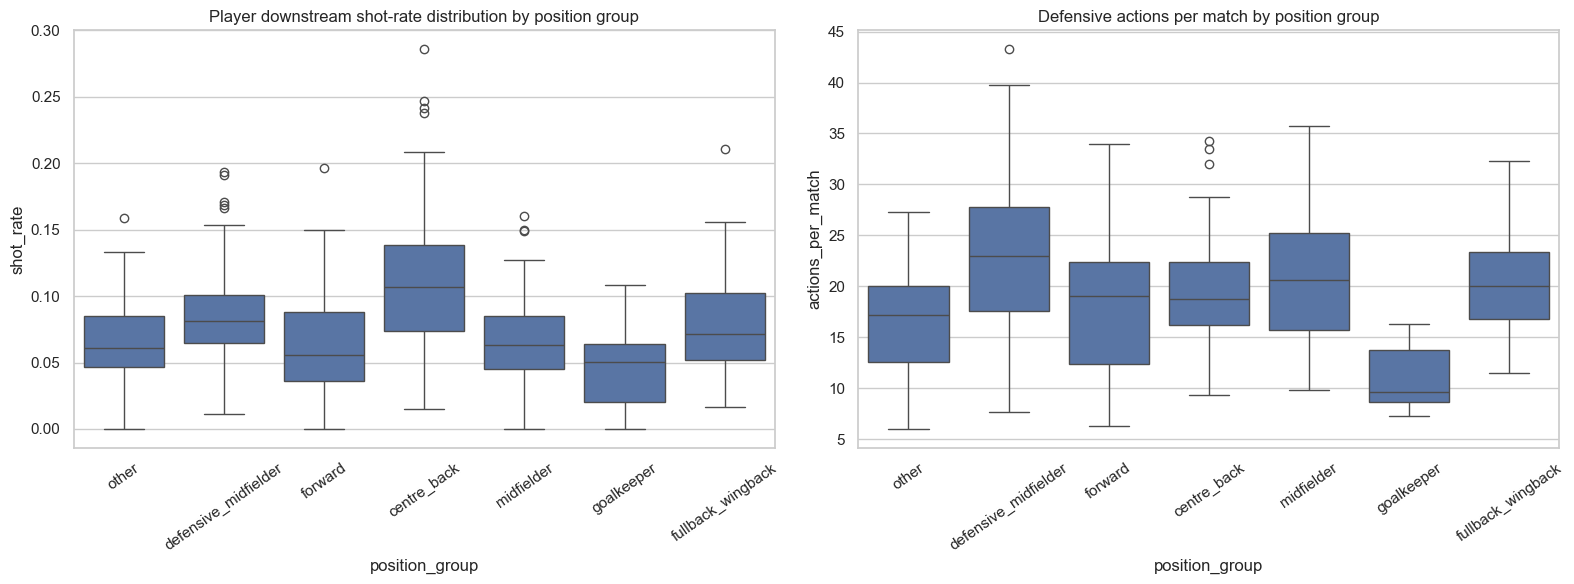

In [3]:
position_summary = (
    profiles.groupby('position_group')
    .agg(
        players=('player_id', 'count'),
        actions=('actions', 'sum'),
        median_actions=('actions', 'median'),
        shot_rate=('shot_rate', 'mean'),
        mean_xt=('mean_xt', 'mean'),
        high_press=('phase__high_press', 'mean'),
        low_block=('phase__settled_low_block', 'mean'),
        box_defence=('phase__box_defence', 'mean'),
        pressure=('action__pressure', 'mean'),
    )
    .sort_values('players', ascending=False)
)
display(position_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=profiles, x='position_group', y='shot_rate', ax=axes[0])
axes[0].set_title('Player downstream shot-rate distribution by position group')
axes[0].tick_params(axis='x', rotation=35)
sns.boxplot(data=profiles, x='position_group', y='actions_per_match', ax=axes[1])
axes[1].set_title('Defensive actions per match by position group')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

---
## 3. Fit player archetype clusters

The clustering uses style and context features. Outcome risk is included so archetypes capture whether a pattern is typically followed by danger.

,k,silhouette
0,2,0.5513
1,3,0.2124
2,4,0.1717
3,5,0.1770
4,6,0.1674
5,7,0.1553
6,8,0.1414
7,9,0.1381


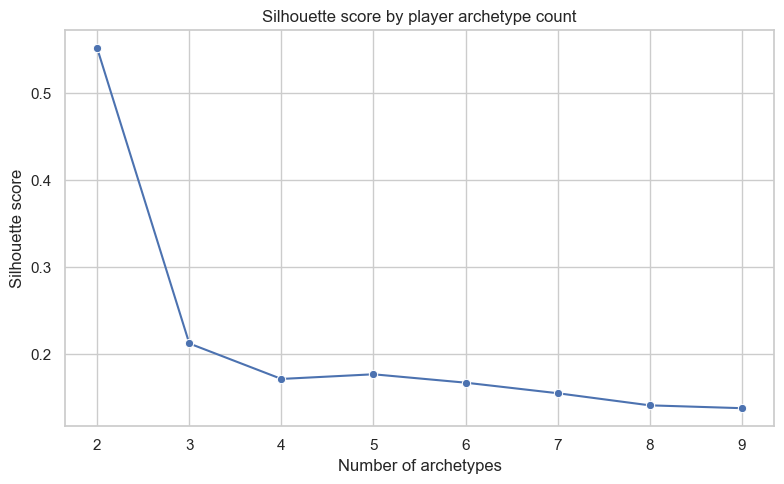

,actions_per_match,shot_rate,mean_xt,has_360_share,counterpress_share,central_lane_share,wide_lane_share,deep_zone_share,high_zone_share,avg_goal_distance,...,phase__box_defence,phase__wide_defending,phase__central_progression_defence,phase__second_ball,action__pressure,action__contest,action__recovery,action__intervention,action__goalkeeper,action__discipline
cluster,,,,,,,,,,,,,,,,,,,,,
0,20.8334,0.1240,0.4590,1.0,0.1151,0.5443,0.1931,0.1559,0.4370,33.0411,...,0.3394,0.0650,0.0870,0.0994,0.3826,0.1171,0.1271,0.3311,0.0000,0.0400
1,22.1851,0.0725,0.4298,1.0,0.1783,0.4581,0.2206,0.1587,0.1846,42.0950,...,0.1138,0.1019,0.1762,0.0864,0.5484,0.1039,0.1550,0.1401,-0.0000,0.0519
2,17.7102,0.1106,0.3910,1.0,0.1202,0.5603,0.1785,0.3321,0.2140,34.2319,...,0.1485,0.0847,0.1146,0.1239,0.3346,0.1412,0.1439,0.3280,0.0000,0.0505
3,11.0995,0.0475,0.2541,1.0,0.0006,0.9183,0.0107,0.4532,0.5340,9.1584,...,0.3079,0.0006,0.0020,0.0000,0.0074,0.0000,0.3519,0.0051,0.6326,0.0016
4,18.8656,0.0701,0.4130,1.0,0.1563,0.2529,0.4561,0.2182,0.2355,41.6856,...,0.1581,0.1893,0.0557,0.1086,0.4961,0.1255,0.1610,0.1716,-0.0000,0.0426
5,18.6026,0.0654,0.4328,1.0,0.1534,0.5140,0.2142,0.2055,0.2180,38.9855,...,0.1448,0.0874,0.1603,0.1647,0.5797,0.1714,0.1154,0.0857,0.0000,0.0473


In [4]:
candidate_features = [
    'actions_per_match', 'shot_rate', 'mean_xt', 'has_360_share', 'counterpress_share',
    'central_lane_share', 'wide_lane_share', 'deep_zone_share', 'high_zone_share',
    'avg_goal_distance', 'avg_support_balance_10m', 'avg_support_ratio_10m',
    'avg_opponent_nearest_distance',
    'phase__high_press', 'phase__counterpress_after_loss', 'phase__settled_low_block',
    'phase__settled_mid_block', 'phase__box_defence', 'phase__wide_defending',
    'phase__central_progression_defence', 'phase__second_ball',
    'action__pressure', 'action__contest', 'action__recovery', 'action__intervention',
    'action__goalkeeper', 'action__discipline',
]
feature_cols = [c for c in candidate_features if c in profiles.columns]

X = profiles[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

max_k = min(9, len(profiles) - 1)
k_results = []
for k in range(2, max_k + 1):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
    k_results.append({'k': k, 'silhouette': score})
k_results = pd.DataFrame(k_results)
display(k_results.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=k_results, x='k', y='silhouette', marker='o', ax=ax)
ax.set_title('Silhouette score by player archetype count')
ax.set_xlabel('Number of archetypes')
ax.set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

N_CLUSTERS = min(6, max(3, len(profiles) // 35))
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=100)
profiles['cluster'] = kmeans.fit_predict(X_scaled)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=feature_cols)
centers['cluster'] = range(N_CLUSTERS)
display(centers.set_index('cluster').round(4))

---
## 4. Label the archetypes

,cluster,archetype,players,actions,avg_actions_per_match,avg_shot_rate,avg_xt,high_press,low_block,box_defence,wide_defending,pressure,contest,recovery
1,1,"Central screeners (High-press hunters-leaning,...",168,17608,22.1851,0.0725,0.4298,0.1353,0.1896,0.1138,0.1019,0.5484,0.1039,0.1550
4,4,Wide-channel protectors (High-press hunters-le...,138,12599,18.8656,0.0701,0.4130,0.1828,0.1614,0.1581,0.1893,0.4961,0.1255,0.1610
0,0,"Risk-exposed defenders (Box defenders-leaning,...",80,5664,20.8334,0.1240,0.4590,0.1172,0.1656,0.3394,0.0650,0.3826,0.1171,0.1271
5,5,"Central screeners (High-press hunters-leaning,...",62,5441,18.6026,0.0654,0.4328,0.1753,0.1455,0.1448,0.0874,0.5797,0.1714,0.1154
2,2,Ball-winning disruptors (High-press hunters-le...,49,4716,17.7102,0.1106,0.3910,0.2747,0.0934,0.1485,0.0847,0.3346,0.1412,0.1439
3,3,Goalkeeper / last-line actors (Box defenders-l...,21,1340,11.0995,0.0475,0.2541,0.2269,0.0136,0.3079,0.0006,0.0074,0.0000,0.3519


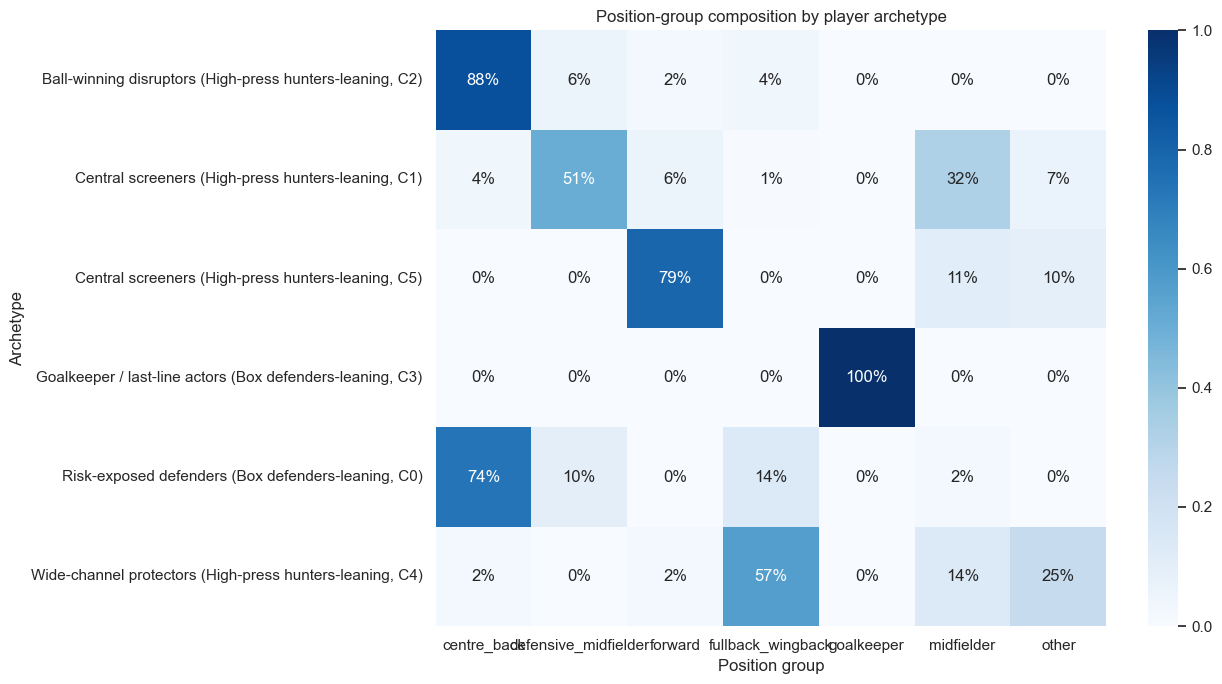

In [5]:
center_matrix = centers.set_index('cluster').copy()
center_z = (center_matrix - center_matrix.mean()) / center_matrix.std(ddof=0).replace(0, 1)

style_components = {
    'High-press hunters': ['phase__high_press', 'phase__counterpress_after_loss', 'counterpress_share', 'action__pressure'],
    'Box defenders': ['phase__box_defence', 'phase__settled_low_block', 'deep_zone_share'],
    'Wide-channel protectors': ['phase__wide_defending', 'wide_lane_share'],
    'Ball-winning disruptors': ['action__contest', 'action__recovery', 'action__intervention'],
    'Central screeners': ['phase__central_progression_defence', 'central_lane_share', 'phase__settled_mid_block'],
    'Goalkeeper / last-line actors': ['action__goalkeeper'],
    'Risk-exposed defenders': ['shot_rate', 'mean_xt'],
}

style_scores = pd.DataFrame(index=center_z.index)
for style_name, style_cols in style_components.items():
    valid_cols = [c for c in style_cols if c in center_z.columns]
    if valid_cols:
        style_scores[style_name] = center_z[valid_cols].sum(axis=1)
    else:
        style_scores[style_name] = -999.0

archetype_labels = {}
for cluster_id, score_row in style_scores.iterrows():
    ranked = score_row.sort_values(ascending=False)
    primary = ranked.index[0]
    secondary = ranked.index[1] if len(ranked) > 1 else primary
    archetype_labels[cluster_id] = f'{primary} ({secondary}-leaning, C{int(cluster_id)})'

profiles['archetype'] = profiles['cluster'].map(archetype_labels)

archetype_summary = (
    profiles.groupby(['cluster', 'archetype'])
    .agg(
        players=('player_id', 'count'),
        actions=('actions', 'sum'),
        avg_actions_per_match=('actions_per_match', 'mean'),
        avg_shot_rate=('shot_rate', 'mean'),
        avg_xt=('mean_xt', 'mean'),
        high_press=('phase__high_press', 'mean'),
        low_block=('phase__settled_low_block', 'mean'),
        box_defence=('phase__box_defence', 'mean'),
        wide_defending=('phase__wide_defending', 'mean'),
        pressure=('action__pressure', 'mean'),
        contest=('action__contest', 'mean'),
        recovery=('action__recovery', 'mean'),
    )
    .reset_index()
    .sort_values('players', ascending=False)
)
display(archetype_summary.round(4))

composition = pd.crosstab(profiles['archetype'], profiles['position_group'], normalize='index')
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(composition, cmap='Blues', annot=True, fmt='.0%', ax=ax)
ax.set_title('Position-group composition by player archetype')
ax.set_xlabel('Position group')
ax.set_ylabel('Archetype')
plt.tight_layout()
plt.show()

---
## 5. Archetype map and centroid heatmap

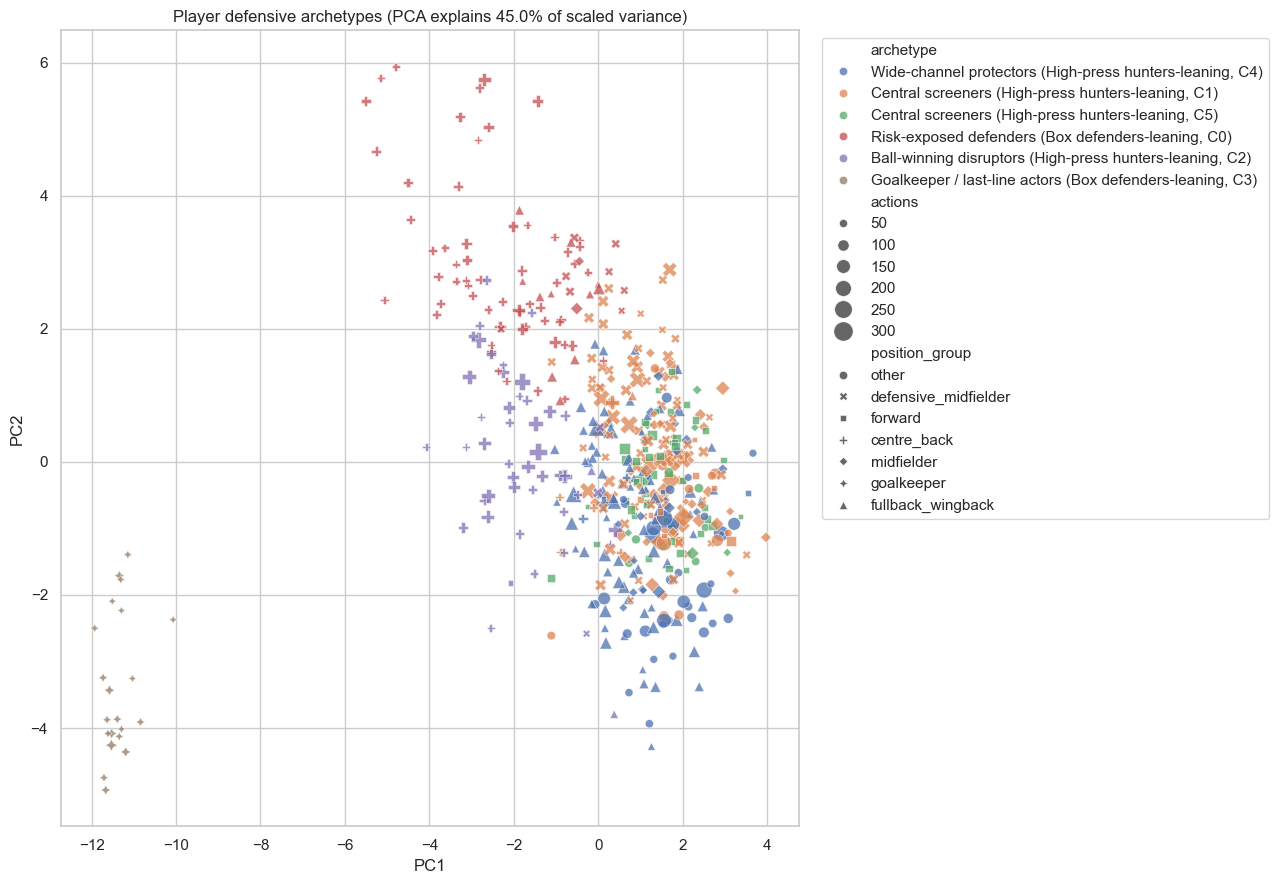

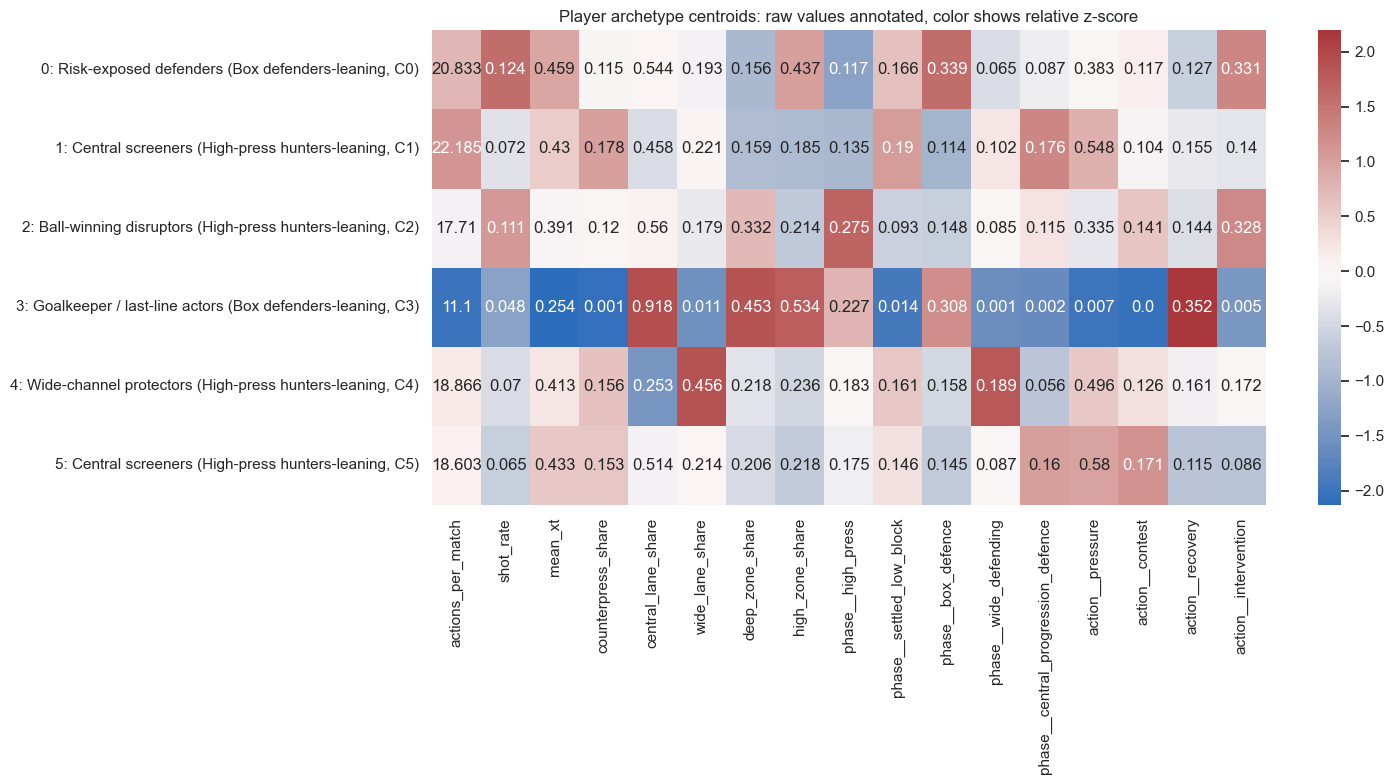

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
profiles['pc1'] = coords[:, 0]
profiles['pc2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(13, 9))
sns.scatterplot(
    data=profiles,
    x='pc1', y='pc2',
    hue='archetype',
    style='position_group',
    size='actions',
    sizes=(30, 220),
    alpha=0.75,
    ax=ax,
)
ax.set_title(f'Player defensive archetypes (PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of scaled variance)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

heat_cols = [c for c in [
    'actions_per_match', 'shot_rate', 'mean_xt', 'counterpress_share', 'central_lane_share', 'wide_lane_share',
    'deep_zone_share', 'high_zone_share', 'phase__high_press', 'phase__settled_low_block', 'phase__box_defence',
    'phase__wide_defending', 'phase__central_progression_defence', 'action__pressure', 'action__contest',
    'action__recovery', 'action__intervention',
] if c in centers.columns]
center_plot = centers.set_index('cluster')[heat_cols]
center_plot.index = [f"{idx}: {archetype_labels[idx]}" for idx in center_plot.index]
center_z = (center_plot - center_plot.mean()) / center_plot.std(ddof=0).replace(0, 1)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(center_z, cmap='vlag', center=0, annot=center_plot.round(3), fmt='', ax=ax)
ax.set_title('Player archetype centroids: raw values annotated, color shows relative z-score')
plt.tight_layout()
plt.show()

---
## 6. Exemplars and low-risk players by role

`distance_to_archetype_center` identifies players closest to the K-Means centroid. Low shot rate should be read with context: role, team strength, and action volume all matter.

In [7]:
distances = kmeans.transform(X_scaled)
profiles['distance_to_archetype_center'] = [distances[i, c] for i, c in enumerate(profiles['cluster'])]

exemplar_cols = ['archetype', 'player', 'primary_team', 'primary_position', 'position_group', 'matches', 'actions', 'shot_rate', 'mean_xt', 'distance_to_archetype_center']
exemplars = (
    profiles.sort_values('distance_to_archetype_center')
    .groupby('archetype', as_index=False)
    .head(8)
    .sort_values(['archetype', 'distance_to_archetype_center'])
)
print('Closest archetype exemplars')
display(exemplars[exemplar_cols].round(4))

print('Lowest-risk retained players within each position group (minimum volume already applied)')
low_risk = (
    profiles.sort_values(['position_group', 'shot_rate', 'mean_xt'])
    .groupby('position_group', as_index=False)
    .head(8)
)
display(low_risk[['position_group', 'player', 'primary_team', 'primary_position', 'archetype', 'matches', 'actions', 'shot_rate', 'mean_xt']].round(4))

print('Highest-volume retained players')
display(profiles.sort_values('actions', ascending=False)[['player', 'primary_team', 'position_group', 'archetype', 'matches', 'actions', 'actions_per_match', 'shot_rate']].head(20).round(4))

Closest archetype exemplars


,archetype,player,primary_team,primary_position,position_group,matches,actions,shot_rate,mean_xt,distance_to_archetype_center
190,Ball-winning disruptors (High-press hunters-le...,Fabian Lukas Schär,Switzerland,Right Center Back,centre_back,7,153,0.0915,0.3707,1.6054
142,Ball-winning disruptors (High-press hunters-le...,Rúben Santos Gato Alves Dias,Portugal,Right Center Back,centre_back,8,122,0.1148,0.3646,1.7176
371,Ball-winning disruptors (High-press hunters-le...,Dayotchanculle Upamecano,France,Left Center Back,centre_back,11,226,0.1239,0.4232,1.7951
42,Ball-winning disruptors (High-press hunters-le...,Nathan Aké,Netherlands,Left Center Back,centre_back,11,186,0.1183,0.3961,1.9064
330,Ball-winning disruptors (High-press hunters-le...,Stefan de Vrij,Netherlands,Right Center Back,centre_back,6,104,0.0769,0.4133,2.2224
762,Ball-winning disruptors (High-press hunters-le...,Joško Gvardiol,Croatia,Left Center Back,centre_back,10,258,0.0775,0.3998,2.2245
47,Ball-winning disruptors (High-press hunters-le...,Harry Maguire,England,Left Center Back,centre_back,5,76,0.0789,0.3741,2.3330
392,Ball-winning disruptors (High-press hunters-le...,Jannik Vestergaard,Denmark,Center Back,centre_back,4,65,0.1385,0.3583,2.3598
183,"Central screeners (High-press hunters-leaning,...",Antoine Griezmann,France,Center Attacking Midfield,midfielder,13,288,0.0521,0.4475,1.7447
7,"Central screeners (High-press hunters-leaning,...",Adrien Rabiot,France,Left Defensive Midfield,defensive_midfielder,11,235,0.0596,0.4034,1.9240


Lowest-risk retained players within each position group (minimum volume already applied)


,position_group,player,primary_team,primary_position,archetype,matches,actions,shot_rate,mean_xt
808,centre_back,Piero Martín Hincapié Reyna,Ecuador,Left Center Back,"Central screeners (High-press hunters-leaning,...",3,67,0.0149,0.3595
675,centre_back,Lisandro Martínez,Argentina,Left Center Back,Wide-channel protectors (High-press hunters-le...,5,52,0.0192,0.3026
19,centre_back,Nicolás Hernán Otamendi,Argentina,Left Center Back,Ball-winning disruptors (High-press hunters-le...,7,156,0.0321,0.3755
40,centre_back,Thiago Emiliano da Silva,Brazil,Left Center Back,Ball-winning disruptors (High-press hunters-le...,4,58,0.0345,0.2814
264,centre_back,Kendall Jamaal Waston Manley,Costa Rica,Right Center Back,Ball-winning disruptors (High-press hunters-le...,3,55,0.0364,0.4290
262,centre_back,Niklas Süle,Germany,Right Center Back,"Central screeners (High-press hunters-leaning,...",3,54,0.0370,0.4254
17,centre_back,Ben Davies,Wales,Left Center Back,Wide-channel protectors (High-press hunters-le...,3,70,0.0429,0.4353
571,centre_back,Toby Alderweireld,Belgium,Right Center Back,Ball-winning disruptors (High-press hunters-le...,3,46,0.0435,0.3874
338,defensive_midfielder,Teun Koopmeiners,Netherlands,Right Defensive Midfield,"Central screeners (High-press hunters-leaning,...",5,86,0.0116,0.3502
533,defensive_midfielder,Leandro Daniel Paredes,Argentina,Right Defensive Midfield,"Central screeners (High-press hunters-leaning,...",5,75,0.0133,0.3952


Highest-volume retained players


,player,primary_team,position_group,archetype,matches,actions,actions_per_match,shot_rate
730,Jude Bellingham,England,midfielder,"Central screeners (High-press hunters-leaning,...",12,345,28.7500,0.0493
183,Antoine Griezmann,France,midfielder,"Central screeners (High-press hunters-leaning,...",13,288,22.1538,0.0521
172,Mateo Kovačić,Croatia,midfielder,"Central screeners (High-press hunters-leaning,...",10,282,28.2000,0.0851
174,Luka Modrić,Croatia,midfielder,"Central screeners (High-press hunters-leaning,...",10,277,27.7000,0.0722
175,Marcelo Brozović,Croatia,defensive_midfielder,"Central screeners (High-press hunters-leaning,...",9,268,29.7778,0.0634
293,Remo Freuler,Switzerland,defensive_midfielder,"Central screeners (High-press hunters-leaning,...",9,261,29.0000,0.0575
101,Declan Rice,England,defensive_midfielder,"Central screeners (High-press hunters-leaning,...",12,259,21.5833,0.0888
762,Joško Gvardiol,Croatia,centre_back,Ball-winning disruptors (High-press hunters-le...,10,258,25.8000,0.0775
433,Aurélien Djani Tchouaméni,France,defensive_midfielder,"Central screeners (High-press hunters-leaning,...",12,237,19.7500,0.1055
7,Adrien Rabiot,France,defensive_midfielder,"Central screeners (High-press hunters-leaning,...",11,235,21.3636,0.0596


---
## 7. Analyst summary

In [8]:
print('=' * 90)
print('PLAYER DEFENSIVE ARCHETYPE SUMMARY')
print('=' * 90)
print(f'Players clustered: {len(profiles):,}')
print(f'Archetypes: {N_CLUSTERS}')
print(f'Features used: {len(feature_cols)}')
print()

for _, row in archetype_summary.iterrows():
    subset = profiles[profiles['cluster'] == row['cluster']].sort_values('distance_to_archetype_center')
    examples = ', '.join(subset['player'].head(5).tolist())
    print(f"Cluster {int(row['cluster'])}: {row['archetype']}")
    print(f"  Players: {int(row['players'])}; avg shot rate: {row['avg_shot_rate']*100:.2f}%; avg xT: {row['avg_xt']:.3f}")
    print(f"  Style: high press {row['high_press']*100:.1f}%, box defence {row['box_defence']*100:.1f}%, pressure {row['pressure']*100:.1f}%")
    print(f"  Exemplars: {examples}")
    print()

safest = profiles.sort_values(['shot_rate', 'mean_xt']).iloc[0]
print(f"Lowest-risk retained player by shot rate: {safest['player']} ({safest['primary_team']}, {safest['position_group']}) — {safest['shot_rate']*100:.2f}%")

PLAYER DEFENSIVE ARCHETYPE SUMMARY
Players clustered: 518
Archetypes: 6
Features used: 27

Cluster 1: Central screeners (High-press hunters-leaning, C1)
  Players: 168; avg shot rate: 7.25%; avg xT: 0.430
  Style: high press 13.5%, box defence 11.4%, pressure 54.8%
  Exemplars: Antoine Griezmann, Adrien Rabiot, Federico Santiago Valverde Dipetta, Joel Nathaniel Campbell Samuels, Piotr Zieliński

Cluster 4: Wide-channel protectors (High-press hunters-leaning, C4)
  Players: 138; avg shot rate: 7.01%; avg xT: 0.413
  Style: high press 18.3%, box defence 15.8%, pressure 49.6%
  Exemplars: Andrija Živković, Cody Mathès Gakpo, Ivan Perišić, Bukayo Saka, Ruben Vargas

Cluster 0: Risk-exposed defenders (Box defenders-leaning, C0)
  Players: 80; avg shot rate: 12.40%; avg xT: 0.459
  Style: high press 11.7%, box defence 33.9%, pressure 38.3%
  Exemplars: Jakub Piotr Kiwior, Kaan Ayhan, Nico Elvedi, Mykola Matvienko, Young-Gwon Kim

Cluster 5: Central screeners (High-press hunters-leaning, C5)
